# AutoEncoder : compression, espace latent et generation

In [1]:
from src.dataset import load_mnist_dataset, load_shapes_npz
from src.autoencoder import AutoEncoder
from src.helper import extract_full_dataset, get_device
from src.metrics import compression_report, Latent

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

print("device:", get_device())


EPOCHS = 15
EPOCHS_SWEEP = 6
BATCH_SIZE = 128

device: cpu


In [2]:
def flattened_vector_to_image(flat_vector, image_shape):
    channels, height, width = image_shape
    image = flat_vector.reshape(channels, height, width)
    return image[0] if channels == 1 else np.transpose(image, (1, 2, 0))

def show_original_vs_reconstruction_grid(originals, reconstructions, image_shape, n=8, title=None):
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(2, n, figsize=(n * 1.3, 3))
    for i in range(n):
        axes[0, i].imshow(flattened_vector_to_image(originals[i], image_shape), cmap=cmap)
        axes[1, i].imshow(np.clip(flattened_vector_to_image(reconstructions[i], image_shape), 0, 1), cmap=cmap)
        for row in (0, 1):
            axes[row, i].set_xticks([]); axes[row, i].set_yticks([])
    axes[0, 0].set_ylabel("original"); axes[1, 0].set_ylabel("reconstruit")
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

def show_image_grid(flat_images, image_shape, nrow=4, ncol=8, title=None):
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 1.1, nrow * 1.1))
    for i, ax in enumerate(np.atleast_1d(axes).ravel()):
        ax.axis("off")
        if i < len(flat_images):
            ax.imshow(np.clip(flattened_vector_to_image(flat_images[i], image_shape), 0, 1), cmap=cmap)
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

def show_labeled_image_rows(rows, image_shape, row_labels, n=8, title=None):
    """Une ligne d'images par configuration, etiquetee a gauche: permet de comparer
    plusieurs modeles sur les memes images."""
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(len(rows), n, figsize=(n * 1.3, len(rows) * 1.45))
    axes = np.atleast_2d(axes)
    for row_index, (images, label) in enumerate(zip(rows, row_labels)):
        for col in range(n):
            ax = axes[row_index, col]
            ax.set_xticks([]); ax.set_yticks([])
            if col < len(images):
                ax.imshow(np.clip(flattened_vector_to_image(images[col], image_shape), 0, 1), cmap=cmap)
        axes[row_index, 0].set_ylabel(label, rotation=0, ha="right", va="center", fontsize=9)
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

def plot_latent_scatter(latent_2d, labels, class_names=None, title=None):
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap="tab10", s=6, alpha=0.6)
    if class_names is not None:
        handles, _ = scatter.legend_elements()
        plt.legend(handles, class_names, title="classe", bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        plt.colorbar(scatter, label="chiffre")
    plt.xlabel("z1"); plt.ylabel("z2")
    if title:
        plt.title(title)
    plt.tight_layout(); plt.show()

def print_compression_report(report):
    for key, value in report.items():
        print(f"{key:>24}: {value:,.4f}" if isinstance(value, float) else f"{key:>24}: {value}")

def sample_gaussian_latent(latent_codes, n_samples, seed=0):
    rng = np.random.default_rng(seed)
    mean = latent_codes.mean(axis=0)
    cov = np.cov(latent_codes, rowvar=False)
    return rng.multivariate_normal(mean, cov, size=n_samples).astype(np.float32)

def generate_from_latent(model, latent, n_samples, seed=0):
    """Genere de nouvelles images en decodant des codes tires d'une gaussienne
    ajustee sur les codes observes."""
    codes = sample_gaussian_latent(latent.array, n_samples, seed=seed)
    return model.decode(Latent(array=codes, nature="continuous"))

def interpolate_latent(z_start, z_end, steps=10):
    alphas = np.linspace(0, 1, steps)[:, None]
    return ((1 - alphas) * z_start[None, :] + alphas * z_end[None, :]).astype(np.float32)

def run_autoencoder_hyperparam_experiment(
        X_train, X_eval, input_dim, latent_dim, activation, epochs, loss_function=nn.MSELoss
        ):
    """Entraine un AutoEncoder et renvoie le modele et ses sorties d'evaluation,
    afin de pouvoir ensuite visualiser reconstruction, generation et espace latent
    sans reentrainer."""
    model = AutoEncoder(input_dim=input_dim, output_dim=input_dim, latent_dim=latent_dim,
                        encoder_layer_num=3, decoder_layer_num=3, encoder_activation=activation,
                        fonction_loss=loss_function)
    model.fit(X_train, epochs=epochs, batch_size=BATCH_SIZE)
    latent = model.encode(X_eval)
    reconstruction = model.decode(latent)
    report = compression_report(model.get_codebook(), latent, X_eval, reconstruction)
    return {"model": model, "latent": latent, "reconstruction": reconstruction, "report": report}

def subsample_dataset(images, labels, n, seed=0):
    if n >= len(images):
        return images, labels
    idx = np.random.default_rng(seed).choice(len(images), size=n, replace=False)
    return images[idx], labels[idx]

## Partie A - MNIST DIGITS

In [3]:
mnist_train_images, mnist_train_labels = extract_full_dataset(load_mnist_dataset(train=True, shuffle=False))
mnist_eval_images, mnist_eval_labels = extract_full_dataset(load_mnist_dataset(train=False, shuffle=False))

MNIST_SHAPE = (1, 28, 28)
X_mnist_train, y_mnist_train = subsample_dataset(
    mnist_train_images.reshape(len(mnist_train_images), -1).numpy(), mnist_train_labels.numpy(), 15000
    )
X_mnist_eval, y_mnist_eval = subsample_dataset(
    mnist_eval_images.reshape(len(mnist_eval_images), -1).numpy(), mnist_eval_labels.numpy(), 3000
    )
print("train:", X_mnist_train.shape, "| eval:", X_mnist_eval.shape)

train: (15000, 784) | eval: (3000, 784)


### Train - ReLu et MSE comme baseline

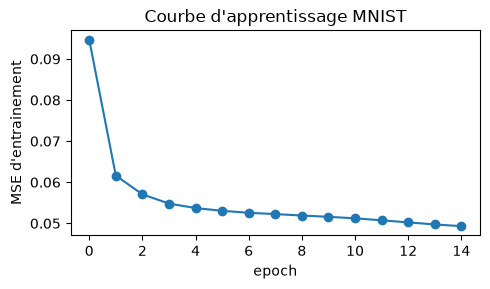

In [4]:
mnist_model = AutoEncoder(
    input_dim=784, output_dim=784, latent_dim=2,
    encoder_layer_num=3, decoder_layer_num=3, encoder_activation=nn.ReLU, fonction_loss=nn.MSELoss
)
mnist_model.fit(X_mnist_train, epochs=EPOCHS, batch_size=BATCH_SIZE)

plt.figure(figsize=(5, 3))
plt.plot(mnist_model.loss_history, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE d'entrainement"); plt.title("Courbe d'apprentissage MNIST")
plt.tight_layout(); plt.show()

### Compression et decompression

code latent par image: 2 valeurs | nature: continuous


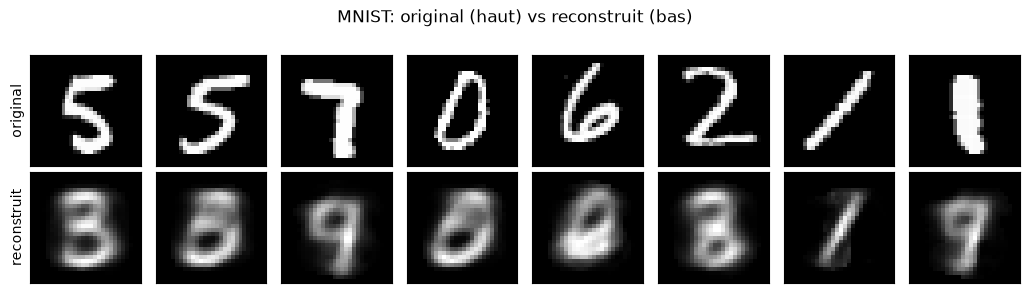

In [5]:
mnist_latent = mnist_model.encode(X_mnist_eval)
mnist_reconstructed = mnist_model.decode(mnist_latent)
print("code latent par image:", mnist_latent.array.shape[1], "valeurs | nature:", mnist_latent.nature)
show_original_vs_reconstruction_grid(X_mnist_eval, mnist_reconstructed, MNIST_SHAPE, n=8,
                     title="MNIST: original (haut) vs reconstruit (bas)")

### Qualite de reconstruction et taille du message

In [6]:
mnist_report = compression_report(mnist_model.get_codebook(), mnist_latent, X_mnist_eval, mnist_reconstructed)
print_compression_report(mnist_report)

per_image_bytes = mnist_latent.n_bytes / len(X_mnist_eval)
print(f"\nMessage transmis par image: {per_image_bytes:.0f} octets ({mnist_latent.array.shape[1]} float32),")
print(f"contre {X_mnist_eval[0].nbytes} octets pour l'image originale en float32.")
print(f"Codebook (poids du decodeur): {mnist_report['codebook_bytes']:,} octets, partage une seule fois.")

           latent_nature: continuous
          codebook_bytes: 345276
            latent_bytes: 24000
  total_compressed_bytes: 369276
          original_bytes: 9408000
       compression_ratio: 25.4769
      reconstruction_mse: 0.0488

Message transmis par image: 8 octets (2 float32),
contre 3136 octets pour l'image originale en float32.
Codebook (poids du decodeur): 345,276 octets, partage une seule fois.


### Visualisation de l'espace latent

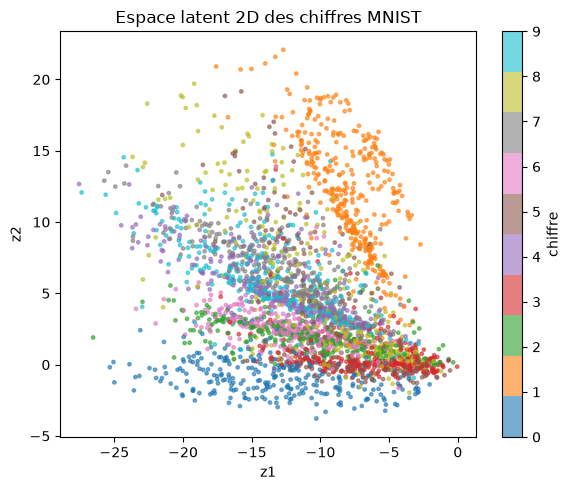

In [7]:
plot_latent_scatter(mnist_latent.array, y_mnist_eval, title="Espace latent 2D des chiffres MNIST")

### Generation de nouvelles images

Le decodeur seul est un generateur: on lui fournit des codes latents inedits.

- Echantillonnage gaussien: on ajuste une gaussienne sur les codes du jeu d'evaluation et on en tire de nouveaux.
- Interpolation: on relie deux images reelles par une droite dans l'espace latent.
- Balayage de la variete 2D: on decode une grille reguliere du plan latent du modele 2D.

Note: un AutoEncoder classique ne contraint pas son espace latent a une loi connue; rester pres de la distribution des donnees (gaussienne ajustee, interpolation) donne les images les plus nettes.

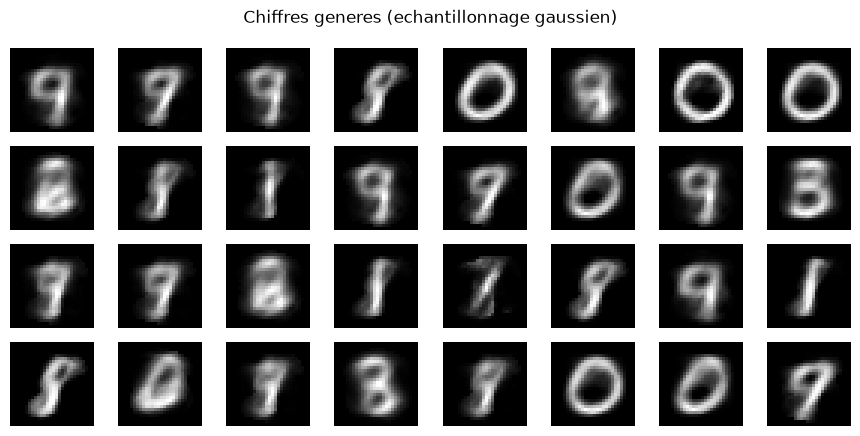

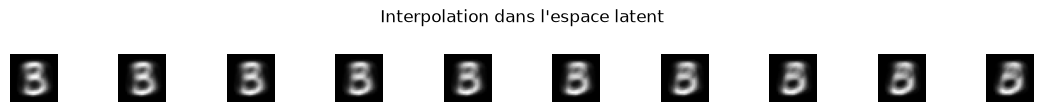

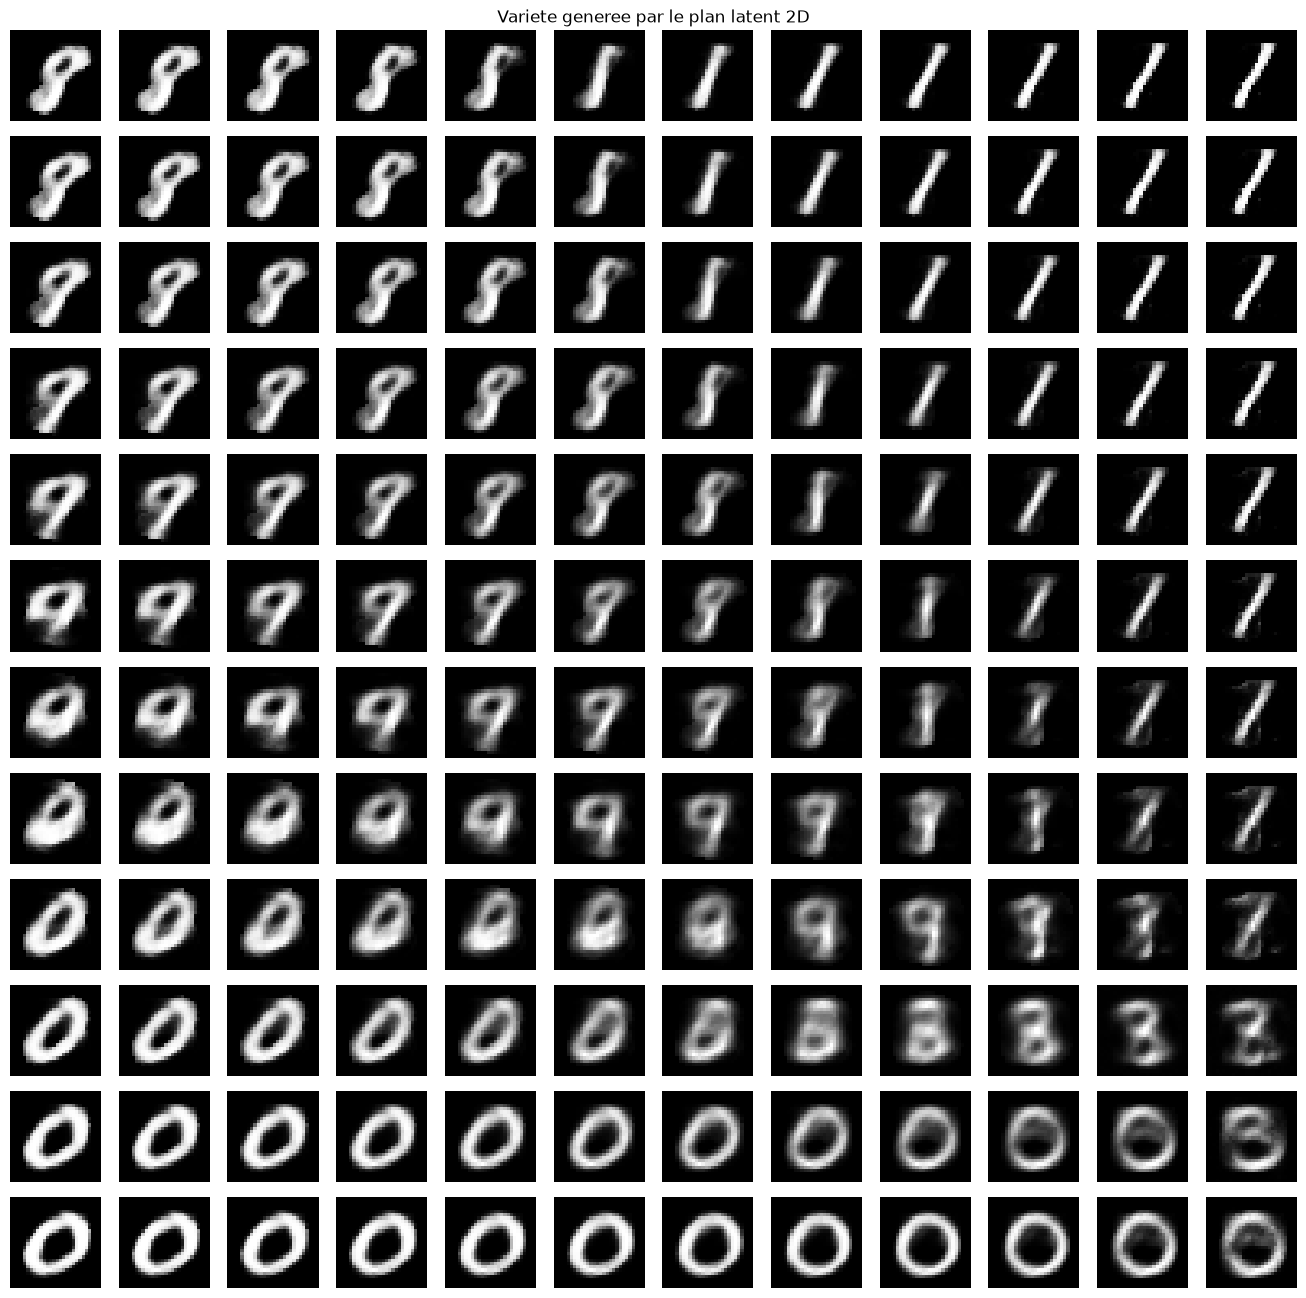

In [8]:
# Echantillonnage gaussien
new_codes = sample_gaussian_latent(mnist_latent.array, n_samples=32)
generated = mnist_model.decode(Latent(array=new_codes, nature="continuous"))
show_image_grid(generated, MNIST_SHAPE, nrow=4, ncol=8, title="Chiffres generes (echantillonnage gaussien)")

# Interpolation entre deux images
path = interpolate_latent(mnist_latent.array[0], mnist_latent.array[1], steps=10)
morph = mnist_model.decode(Latent(array=path, nature="continuous"))
show_image_grid(morph, MNIST_SHAPE, nrow=1, ncol=10, title="Interpolation dans l'espace latent")

# Balayage du latent
lo, hi = mnist_latent.array.min(axis=0), mnist_latent.array.max(axis=0)
grid_axis = 12
xs = np.linspace(lo[0], hi[0], grid_axis)
ys = np.linspace(hi[1], lo[1], grid_axis)
grid = np.array([[x, y] for y in ys for x in xs], dtype=np.float32)
manifold = mnist_model.decode(Latent(array=grid, nature="continuous"))
show_image_grid(manifold, MNIST_SHAPE, nrow=grid_axis, ncol=grid_axis, title="Variete generee par le plan latent 2D")

### Experimentation sur les hyper-parametres

 ReLU | latent= 2 | MSE=0.0570 | total=  369,276 o | ratio=25.48
 ReLU | latent= 8 | MSE=0.0520 | total=  658,712 o | ratio=14.28
 ReLU | latent=16 | MSE=0.0411 | total=  920,688 o | ratio=10.22
 ReLU | latent=32 | MSE=0.0367 | total=1,342,932 o | ratio=7.01
 ReLU | latent=64 | MSE=0.0349 | total=2,076,876 o | ratio=4.53
 Tanh | latent= 2 | MSE=0.0674 | total=  369,276 o | ratio=25.48
 Tanh | latent= 8 | MSE=0.0605 | total=  658,712 o | ratio=14.28
 Tanh | latent=16 | MSE=0.0673 | total=  920,688 o | ratio=10.22
 Tanh | latent=32 | MSE=0.0597 | total=1,342,932 o | ratio=7.01
 Tanh | latent=64 | MSE=0.0613 | total=2,076,876 o | ratio=4.53


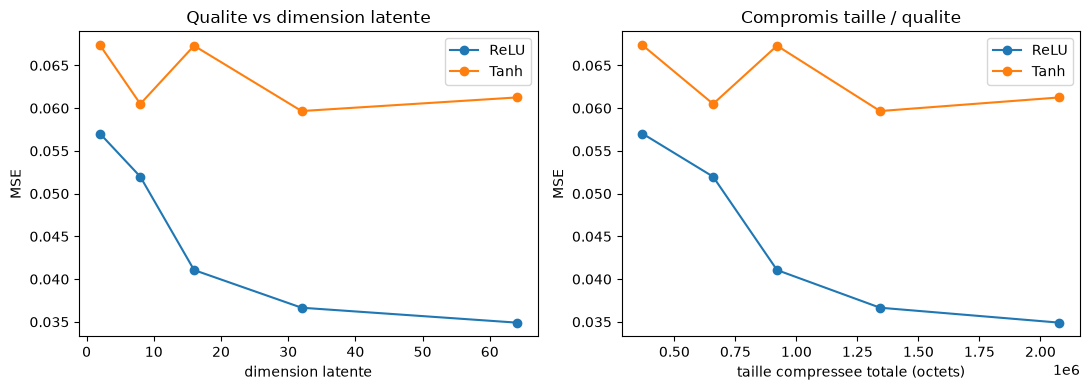

In [9]:
latent_dims = [2, 8, 16, 32, 64]
activations = {"ReLU": nn.ReLU, "Tanh": nn.Tanh}
X_tr, y_tr = subsample_dataset(X_mnist_train, y_mnist_train, 6000, seed=1)

mnist_runs = {}
mnist_results = []
for act_name, act in activations.items():
    for latent_dim in latent_dims:
        run = run_autoencoder_hyperparam_experiment(X_tr, X_mnist_eval, 784, latent_dim, act, EPOCHS_SWEEP)
        mnist_runs[(act_name, latent_dim)] = run
        report = run["report"]
        report.update(latent_dim=latent_dim, activation=act_name)
        mnist_results.append(report)
        print(f"{act_name:>5} | latent={latent_dim:>2} | MSE={report['reconstruction_mse']:.4f} "
              f"| total={report['total_compressed_bytes']:>9,} o | ratio={report['compression_ratio']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for act_name in activations:
    pts = [r for r in mnist_results if r["activation"] == act_name]
    axes[0].plot([r["latent_dim"] for r in pts], [r["reconstruction_mse"] for r in pts], marker="o", label=act_name)
    axes[1].plot([r["total_compressed_bytes"] for r in pts], [r["reconstruction_mse"] for r in pts], marker="o", label=act_name)
axes[0].set_xlabel("dimension latente"); axes[0].set_ylabel("MSE"); axes[0].set_title("Qualite vs dimension latente"); axes[0].legend()
axes[1].set_xlabel("taille compressee totale (octets)"); axes[1].set_ylabel("MSE"); axes[1].set_title("Compromis taille / qualite"); axes[1].legend()
plt.tight_layout(); plt.show()

#### Effet visuel de la dimension latente

Les courbes ci-dessus donnent la MSE, mais pas ce que l'oeil percoit. On reutilise les modeles
deja entraines (activation ReLU) pour comparer, a images identiques, la decompression puis la
generation selon la dimension latente.

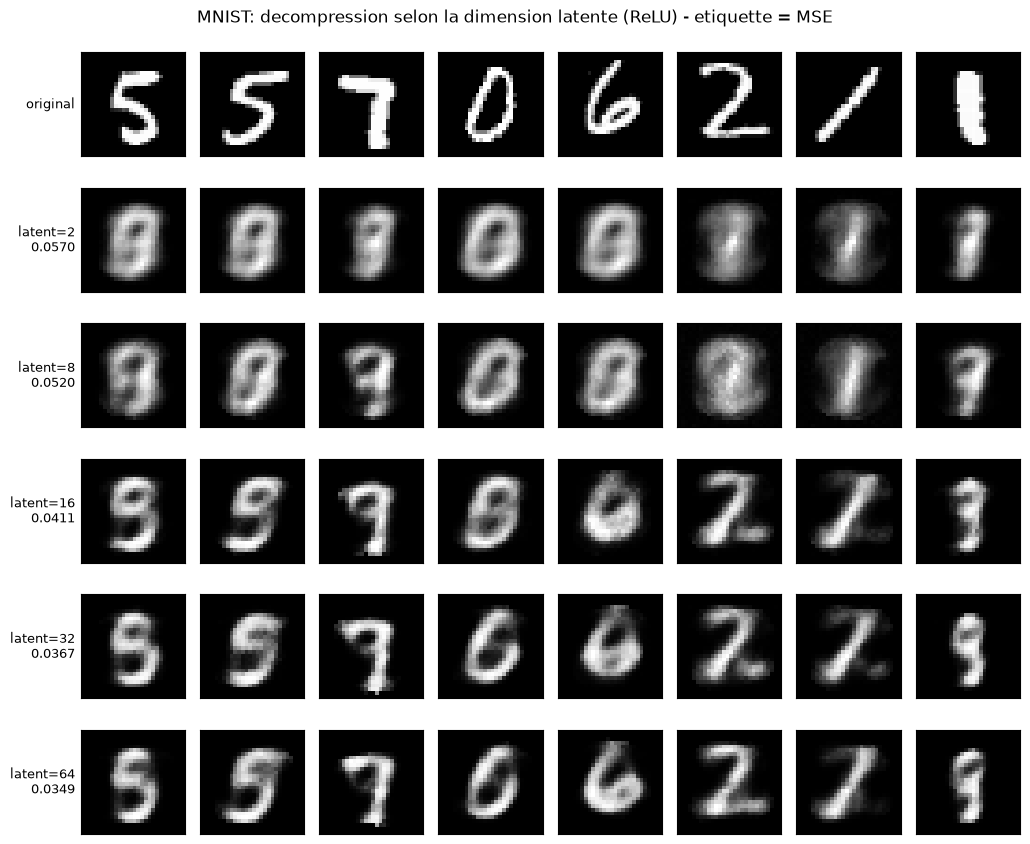

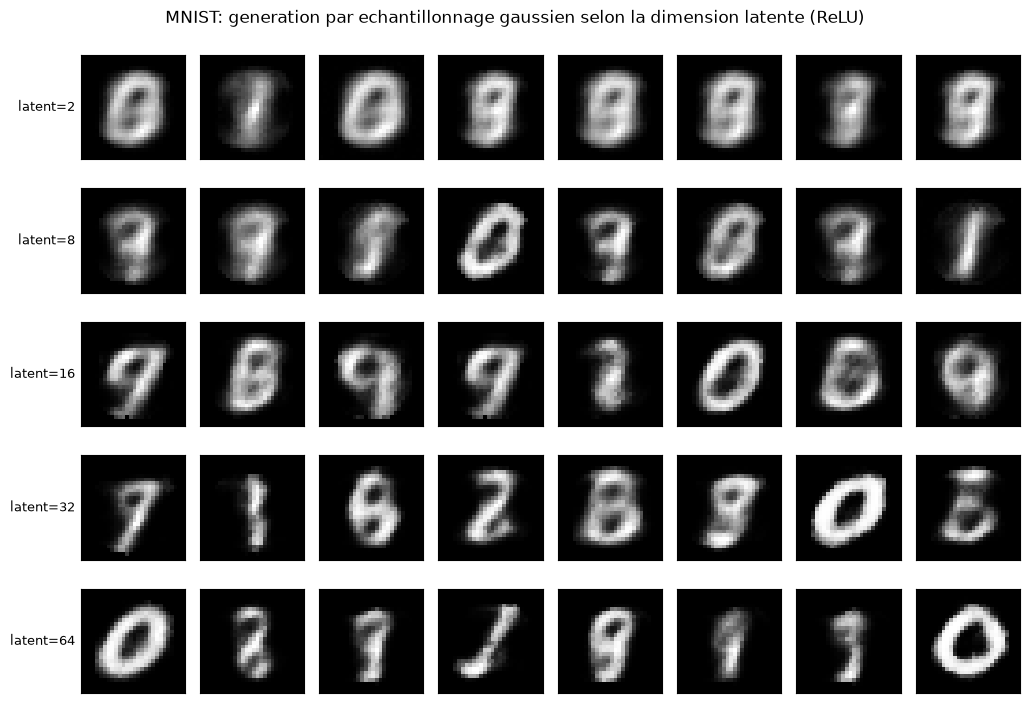

In [ ]:
VIZ_ACTIVATION = "ReLU"

show_labeled_image_rows(
    [X_mnist_eval] + [mnist_runs[(VIZ_ACTIVATION, d)]["reconstruction"] for d in latent_dims],
    MNIST_SHAPE,
    ["original"] + [f"latent={d}\n{mnist_runs[(VIZ_ACTIVATION, d)]['report']['reconstruction_mse']:.4f}" for d in latent_dims],
    n=8, title=f"MNIST: decompression selon la dimension latente ({VIZ_ACTIVATION}) - etiquette = MSE",
)

show_labeled_image_rows(
    [generate_from_latent(mnist_runs[(VIZ_ACTIVATION, d)]["model"], mnist_runs[(VIZ_ACTIVATION, d)]["latent"], 8, seed=1)
     for d in latent_dims],
    MNIST_SHAPE,
    [f"latent={d}" for d in latent_dims],
    n=8, title=f"MNIST: generation par echantillonnage gaussien selon la dimension latente ({VIZ_ACTIVATION})",
)

#### Espace latent selon la fonction d'activation


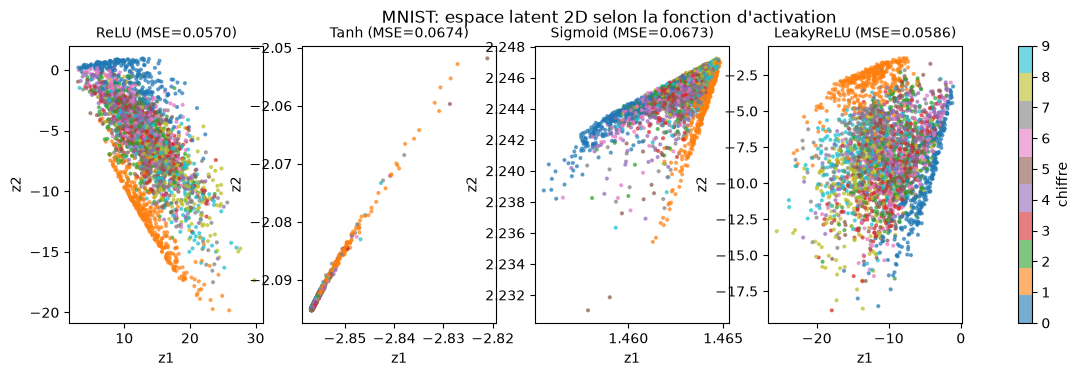

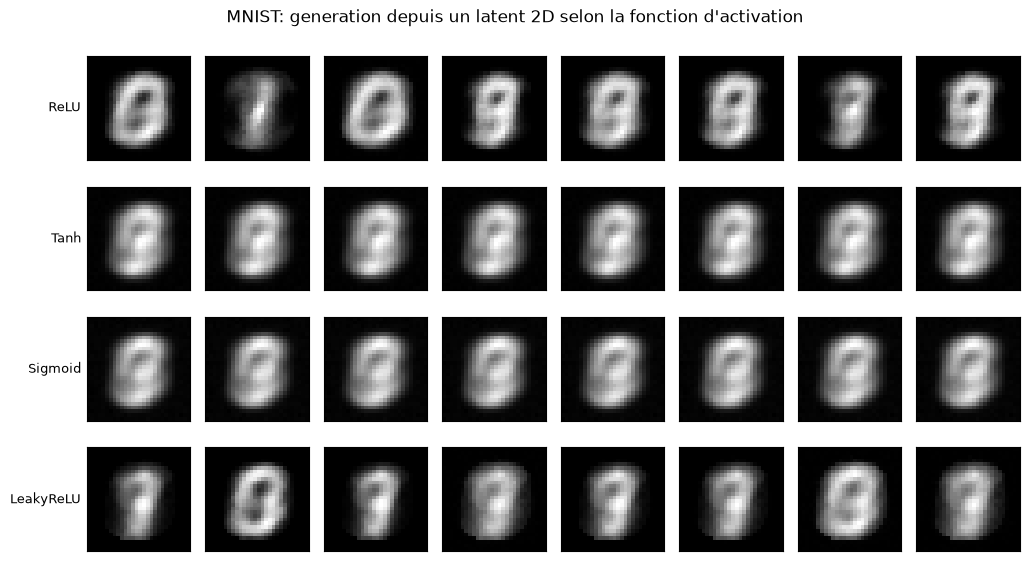

In [ ]:
latent_viz_activations = {"ReLU": nn.ReLU, "Tanh": nn.Tanh, "Sigmoid": nn.Sigmoid, "LeakyReLU": nn.LeakyReLU}

for act_name, act in latent_viz_activations.items():
    if (act_name, 2) not in mnist_runs:
        mnist_runs[(act_name, 2)] = run_autoencoder_hyperparam_experiment(
            X_tr, X_mnist_eval, 784, 2, act, EPOCHS_SWEEP
        )

fig, axes = plt.subplots(1, len(latent_viz_activations), figsize=(3.6 * len(latent_viz_activations), 3.6))
for ax, act_name in zip(axes, latent_viz_activations):
    run = mnist_runs[(act_name, 2)]
    codes = run["latent"].array
    scatter = ax.scatter(codes[:, 0], codes[:, 1], c=y_mnist_eval, cmap="tab10", s=4, alpha=0.6)
    ax.set_title(f"{act_name} (MSE={run['report']['reconstruction_mse']:.4f})", fontsize=10)
    ax.set_xlabel("z1"); ax.set_ylabel("z2")
fig.colorbar(scatter, ax=list(axes), label="chiffre")
fig.suptitle("MNIST: espace latent 2D selon la fonction d'activation")
plt.show()

show_labeled_image_rows(
    [generate_from_latent(mnist_runs[(act_name, 2)]["model"], mnist_runs[(act_name, 2)]["latent"], 8, seed=1)
     for act_name in latent_viz_activations],
    MNIST_SHAPE,
    list(latent_viz_activations),
    n=8, title="MNIST: generation depuis un latent 2D selon la fonction d'activation",
)

### Variation de la fonction de perte
MSE, L1 et BCE

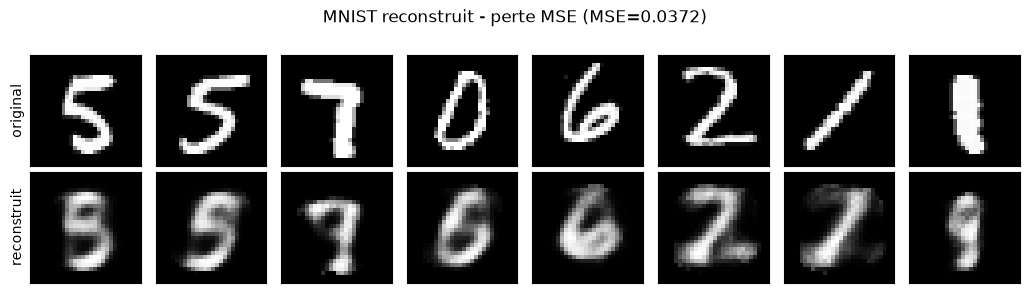

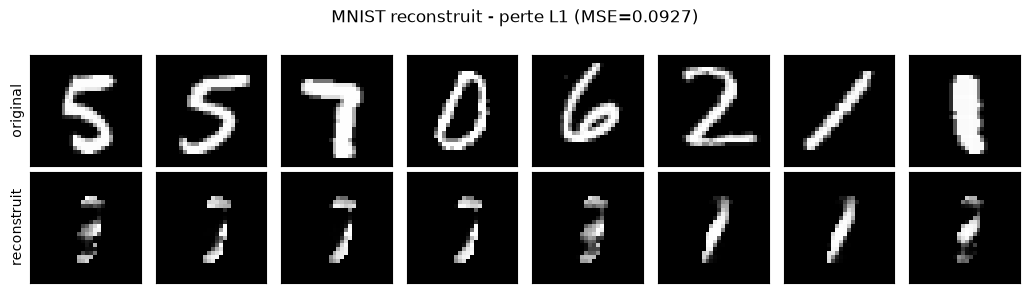

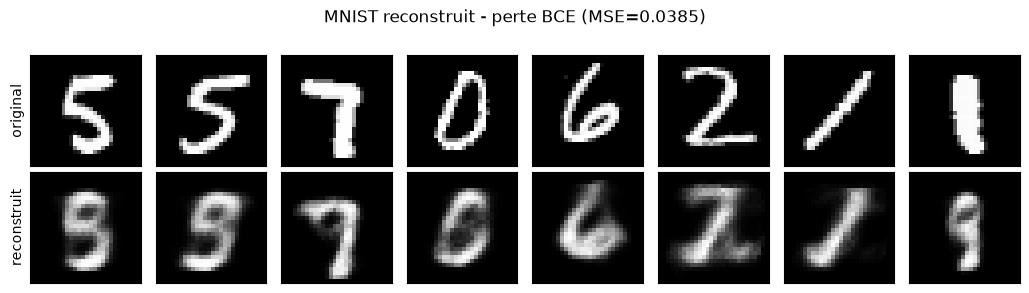

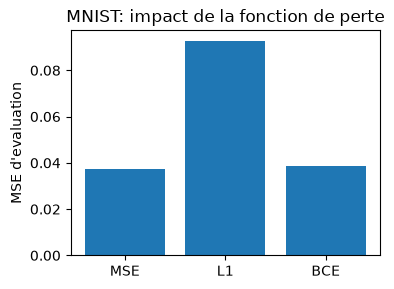

In [12]:
loss_functions = {"MSE": nn.MSELoss, "L1": nn.L1Loss, "BCE": nn.BCELoss}

mnist_loss_mse = {}
for name, loss_cls in loss_functions.items():
    model = AutoEncoder(input_dim=784, output_dim=784, latent_dim=32,
                        encoder_layer_num=3, decoder_layer_num=3,
                        encoder_activation=nn.ReLU, fonction_loss=loss_cls)
    model.fit(X_tr, epochs=EPOCHS_SWEEP, batch_size=BATCH_SIZE)
    latent = model.encode(X_mnist_eval)
    reconstruction = model.decode(latent)
    mnist_loss_mse[name] = compression_report(model.get_codebook(), latent, X_mnist_eval, reconstruction)["reconstruction_mse"]
    show_original_vs_reconstruction_grid(X_mnist_eval, reconstruction, MNIST_SHAPE, n=8,
                         title=f"MNIST reconstruit - perte {name} (MSE={mnist_loss_mse[name]:.4f})")

plt.figure(figsize=(4, 3))
plt.bar(list(mnist_loss_mse), list(mnist_loss_mse.values()))
plt.ylabel("MSE d'evaluation"); plt.title("MNIST: impact de la fonction de perte")
plt.tight_layout(); plt.show()

## Partie B - shapes

train: (12000, 3072) | eval: (3000, 3072) | classes: ['circle', 'square', 'triangle', 'cross', 'star', 'bar']


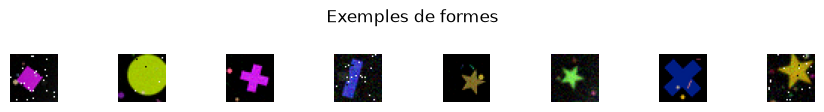

In [13]:
X_shapes_train, y_shapes_train, shape_names = load_shapes_npz(split="train", max_samples=12000)
X_shapes_eval, y_shapes_eval, _ = load_shapes_npz(split="validation", max_samples=3000)
X_shapes_train = X_shapes_train.reshape(len(X_shapes_train), -1)
X_shapes_eval = X_shapes_eval.reshape(len(X_shapes_eval), -1)

SHAPES_SHAPE = (3, 32, 32)
SHAPES_DIM = 3 * 32 * 32
print("train:", X_shapes_train.shape, "| eval:", X_shapes_eval.shape, "| classes:", shape_names)
show_image_grid(X_shapes_eval[:8], SHAPES_SHAPE, nrow=1, ncol=8, title="Exemples de formes")

### Train, compression et decompression

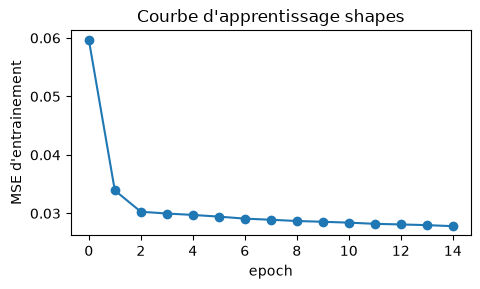

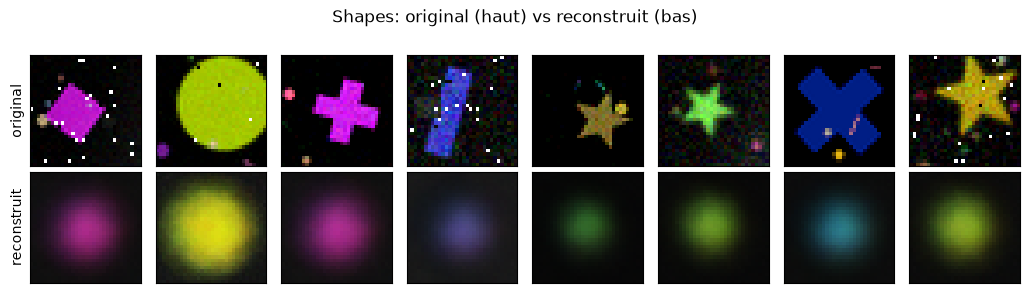

In [14]:
shapes_model = AutoEncoder(input_dim=SHAPES_DIM, output_dim=SHAPES_DIM, latent_dim=2,
                           encoder_layer_num=3, decoder_layer_num=3, encoder_activation=nn.ReLU)
shapes_model.fit(X_shapes_train, epochs=EPOCHS, batch_size=BATCH_SIZE)

plt.figure(figsize=(5, 3))
plt.plot(shapes_model.loss_history, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE d'entrainement"); plt.title("Courbe d'apprentissage shapes")
plt.tight_layout(); plt.show()

shapes_latent = shapes_model.encode(X_shapes_eval)
shapes_reconstructed = shapes_model.decode(shapes_latent)
show_original_vs_reconstruction_grid(X_shapes_eval, shapes_reconstructed, SHAPES_SHAPE, n=8,
                     title="Shapes: original (haut) vs reconstruit (bas)")

### Metriques de compression

In [15]:
shapes_report = compression_report(shapes_model.get_codebook(), shapes_latent, X_shapes_eval, shapes_reconstructed)
print_compression_report(shapes_report)

per_image_bytes = shapes_latent.n_bytes / len(X_shapes_eval)
print(f"\nMessage par image: {per_image_bytes:.0f} octets contre {X_shapes_eval[0].nbytes} octets en float32.")

           latent_nature: continuous
          codebook_bytes: 3306708
            latent_bytes: 24000
  total_compressed_bytes: 3330708
          original_bytes: 36864000
       compression_ratio: 11.0679
      reconstruction_mse: 0.0281

Message par image: 8 octets contre 12288 octets en float32.


### Espace latent et generation

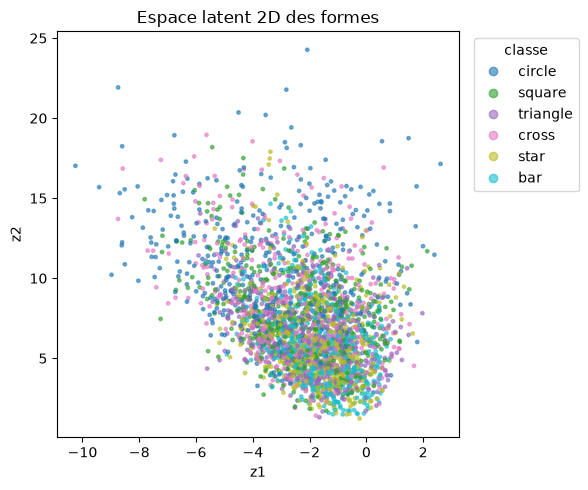

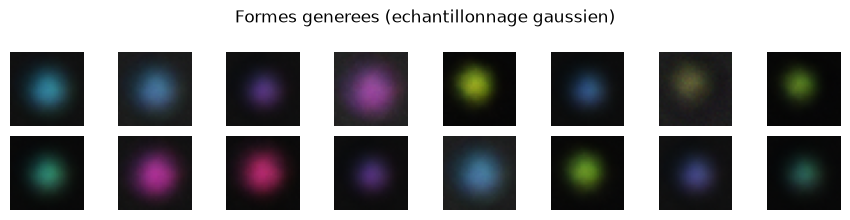

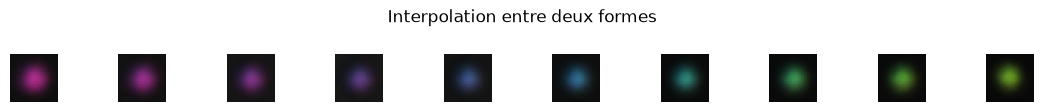

In [16]:
plot_latent_scatter(shapes_latent.array, y_shapes_eval, class_names=shape_names,
                    title="Espace latent 2D des formes")

# Generation par echantillonnage gaussien
new_codes = sample_gaussian_latent(shapes_latent.array, n_samples=16)
generated = shapes_model.decode(Latent(array=new_codes, nature="continuous"))
show_image_grid(generated, SHAPES_SHAPE, nrow=2, ncol=8, title="Formes generees (echantillonnage gaussien)")

# Interpolation entre deux formes
path = interpolate_latent(shapes_latent.array[0], shapes_latent.array[5], steps=10)
morph = shapes_model.decode(Latent(array=path, nature="continuous"))
show_image_grid(morph, SHAPES_SHAPE, nrow=1, ncol=10, title="Interpolation entre deux formes")

### Experimentation hyper-parametres

latent= 2 | MSE=0.0304 | total=3,330,708 o | ratio=11.07
latent= 8 | MSE=0.0205 | total=5,395,504 o | ratio=6.83
latent=16 | MSE=0.0190 | total=6,945,664 o | ratio=5.31
latent=32 | MSE=0.0184 | total=9,042,480 o | ratio=4.08
latent=64 | MSE=0.0186 | total=12,011,508 o | ratio=3.07


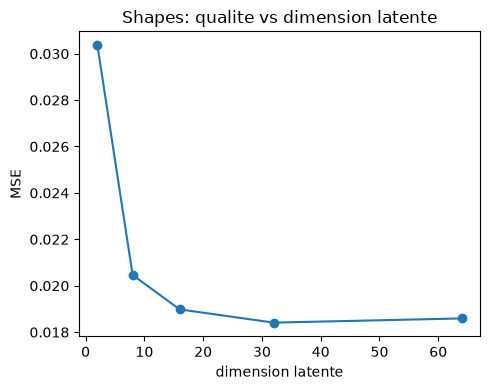

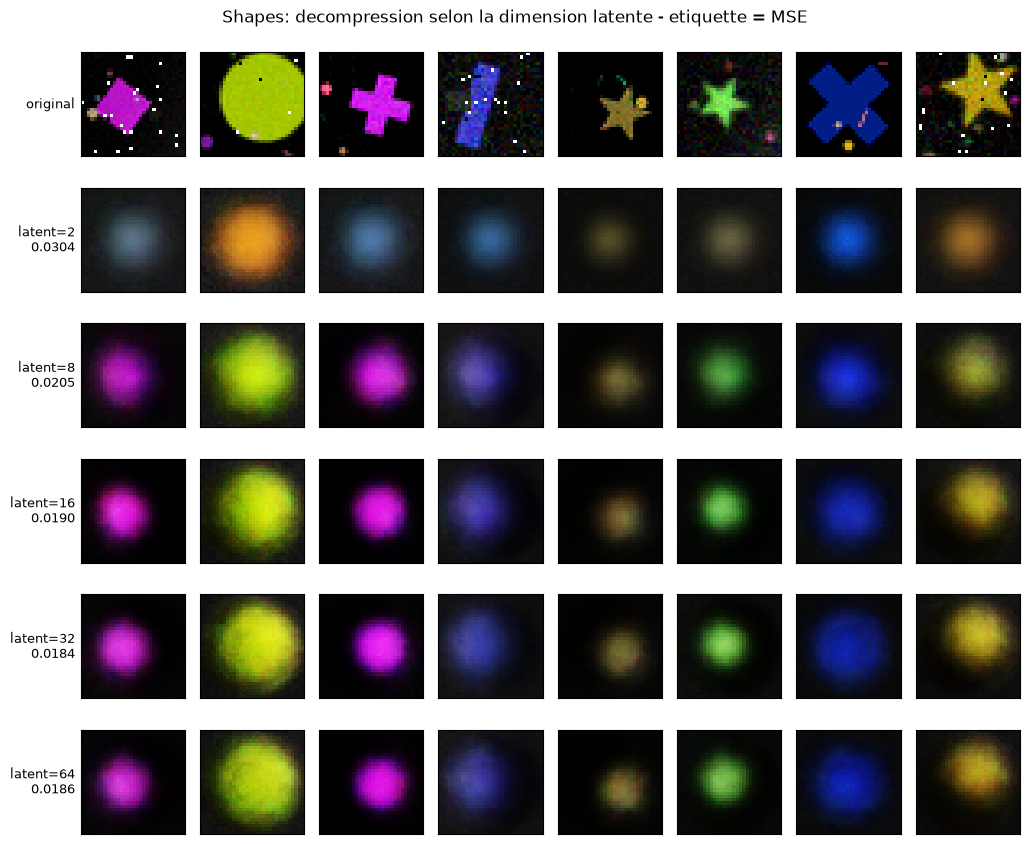

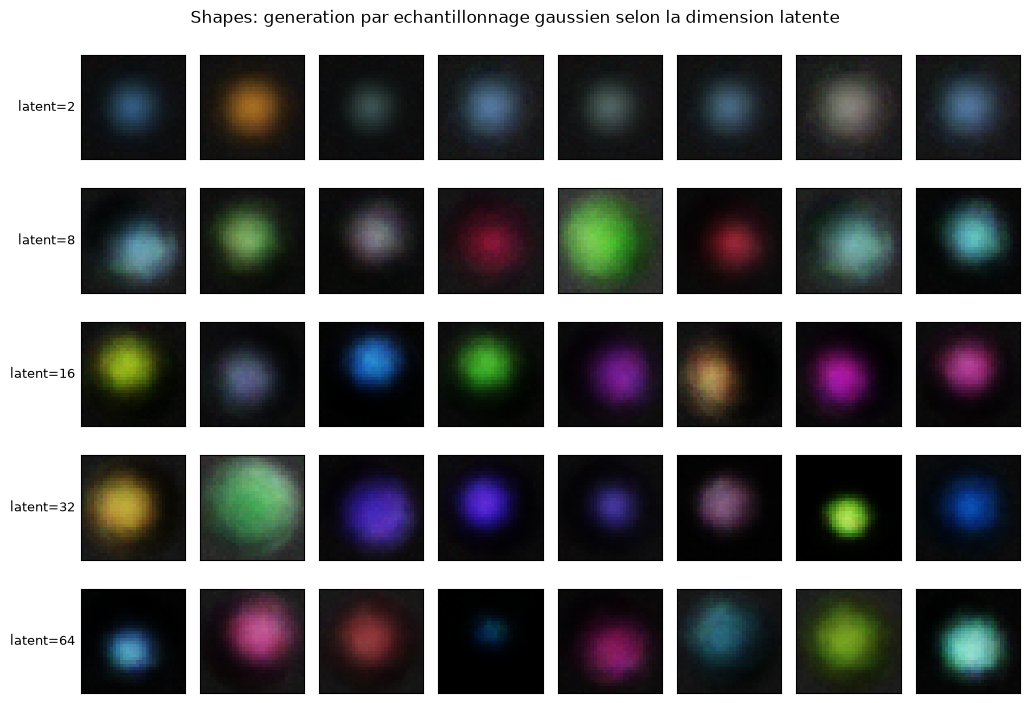

In [17]:
X_shapes_tr, _ = subsample_dataset(X_shapes_train, y_shapes_train, 6000, seed=1)
shapes_runs = {}
shapes_results = []
for latent_dim in latent_dims:
    run = run_autoencoder_hyperparam_experiment(X_shapes_tr, X_shapes_eval, SHAPES_DIM, latent_dim, nn.ReLU, EPOCHS_SWEEP)
    shapes_runs[latent_dim] = run
    report = run["report"]
    report.update(latent_dim=latent_dim)
    shapes_results.append(report)
    print(f"latent={latent_dim:>2} | MSE={report['reconstruction_mse']:.4f} "
          f"| total={report['total_compressed_bytes']:>9,} o | ratio={report['compression_ratio']:.2f}")

plt.figure(figsize=(5, 4))
plt.plot([r["latent_dim"] for r in shapes_results], [r["reconstruction_mse"] for r in shapes_results], marker="o")
plt.xlabel("dimension latente"); plt.ylabel("MSE"); plt.title("Shapes: qualite vs dimension latente")
plt.tight_layout(); plt.show()

# Decompression et generation selon la dimension latente
show_labeled_image_rows(
    [X_shapes_eval] + [shapes_runs[d]["reconstruction"] for d in latent_dims],
    SHAPES_SHAPE,
    ["original"] + [f"latent={d}\n{shapes_runs[d]['report']['reconstruction_mse']:.4f}" for d in latent_dims],
    n=8, title="Shapes: decompression selon la dimension latente - etiquette = MSE",
)

show_labeled_image_rows(
    [generate_from_latent(shapes_runs[d]["model"], shapes_runs[d]["latent"], 8, seed=1) for d in latent_dims],
    SHAPES_SHAPE,
    [f"latent={d}" for d in latent_dims],
    n=8, title="Shapes: generation par echantillonnage gaussien selon la dimension latente",
)

### Variation de la fonction de perte
MSE, L1, BCE

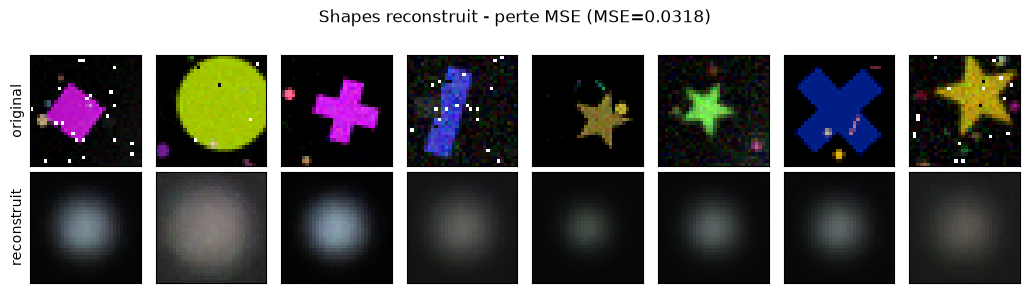

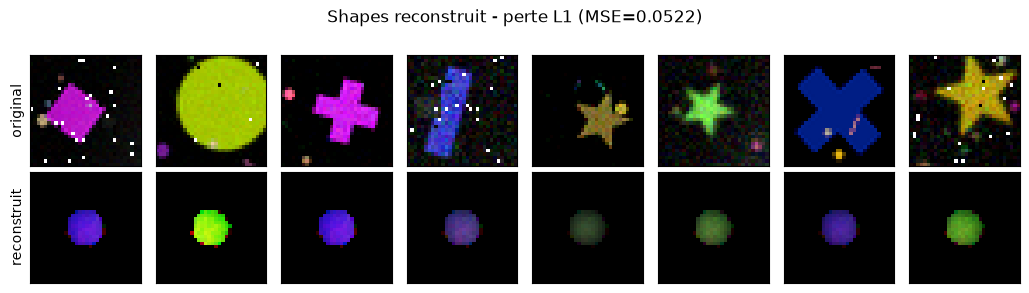

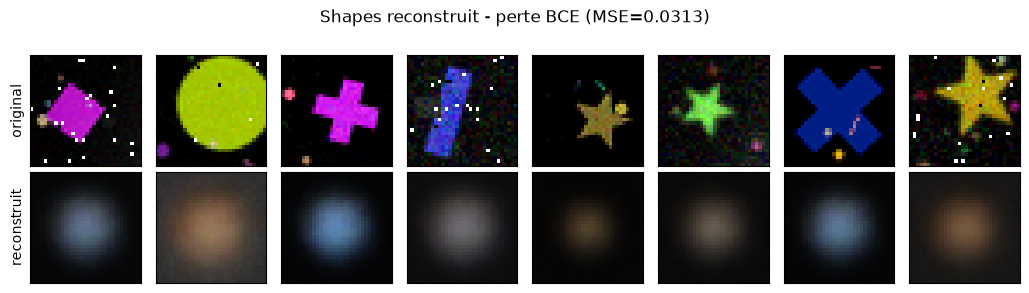

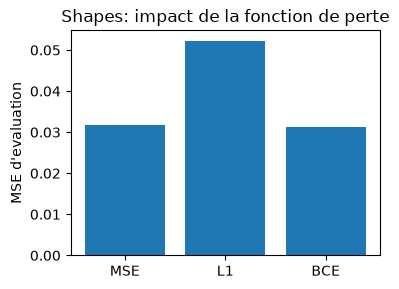

In [18]:
shapes_loss_mse = {}
for name, loss_cls in loss_functions.items():
    model = AutoEncoder(input_dim=SHAPES_DIM, output_dim=SHAPES_DIM, latent_dim=2,
                        encoder_layer_num=3, decoder_layer_num=3,
                        encoder_activation=nn.ReLU, fonction_loss=loss_cls)
    model.fit(X_shapes_tr, epochs=EPOCHS_SWEEP, batch_size=BATCH_SIZE)
    latent = model.encode(X_shapes_eval)
    reconstruction = model.decode(latent)
    shapes_loss_mse[name] = compression_report(model.get_codebook(), latent, X_shapes_eval, reconstruction)["reconstruction_mse"]
    show_original_vs_reconstruction_grid(X_shapes_eval, reconstruction, SHAPES_SHAPE, n=8,
                         title=f"Shapes reconstruit - perte {name} (MSE={shapes_loss_mse[name]:.4f})")

plt.figure(figsize=(4, 3))
plt.bar(list(shapes_loss_mse), list(shapes_loss_mse.values()))
plt.ylabel("MSE d'evaluation"); plt.title("Shapes: impact de la fonction de perte")
plt.tight_layout(); plt.show()

## Reponses aux questions du projet

1. Nature de l'espace latent.

Il est continu: encode renvoie un Latent de nature "continuous", c'est-a-dire un vecteur de reels (float32) dense. N'importe quel point de l'espace peut etre decode, ce qui rend possibles l'interpolation et l'echantillonnage. Cela contraste avec K-Means, dont l'espace latent est discret (un indice de cluster parmi K).

2. Codebook.

Le codebook renvoye par get_codebook regroupe les poids du decodeur. C'est le dictionnaire partage: l'emetteur et le recepteur doivent tous deux en disposer pour reconstruire. Concretement, l'emetteur compresse avec l'encodeur et n'envoie que le code latent; le recepteur applique le decodeur (le codebook) a ce code. Le codebook est un cout fixe, paye une seule fois et amorti sur toutes les images.

3. Qualite de reconstruction.

Mesuree par la MSE de compression_report (voir les tableaux ci-dessus) et visible sur les grilles original vs reconstruit. Elle s'ameliore quand la dimension latente augmente, au prix d'un message plus gros: c'est le compromis illustre par les courbes d'experimentation. Elle depend aussi de la fonction de perte d'entrainement (MSE, L1, BCE).

4. Code byte (taille du message).

Le message transmis par image est le code latent: dimension_latente x 4 octets (float32), soit par exemple 128 octets pour une dimension latente de 32. La taille totale pour un lot est latent_bytes dans compression_report; le codebook s'y ajoute une seule fois, independamment du nombre d'images.